In [1]:
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)

print("All libraries imported!")

All libraries imported!


In [2]:
train_df = pd.read_csv('../data/processed/train_data.csv')
test_df = pd.read_csv('../data/processed/test_data.csv')

X_train = train_df.drop('Risk', axis=1)
y_train = train_df['Risk']

X_test = test_df.drop('Risk', axis=1)
y_test = test_df['Risk']

# Drop rows with missing target values (features are assumed to already be
# cleaned upstream in the preprocessing notebook)
train_mask = ~y_train.isna()
X_train = X_train.loc[train_mask]
y_train = y_train.loc[train_mask]

test_mask = ~y_test.isna()
X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

print("=== Data Loaded ===")
print(f"Train: {X_train.shape}")
print(f"Test : {X_test.shape}")
print(f"\nTrain Class Distribution:")
print(y_train.value_counts())
print(f"\nTrain Class Balance (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

=== Data Loaded ===
Train: (836, 9)
Test : (38, 9)

Train Class Distribution:
Risk
1    418
0    418
Name: count, dtype: int64

Train Class Balance (%):
Risk
1    50.0
0    50.0
Name: proportion, dtype: float64


In [3]:
# Logistic Regression is sensitive to feature scale, so we fit a scaler on the
# training data only and apply it to both train and test. Tree-based models
# (Random Forest, XGBoost) don't need this, so they keep using the unscaled
# X_train / X_test defined above.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # guards against class imbalance in "Risk"
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print("\n=== Logistic Regression Results ===")
print(f"Accuracy : {lr_acc:.4f}")
print(f"AUC Score: {lr_auc:.4f}")

Training Logistic Regression...

=== Logistic Regression Results ===
Accuracy : 0.4211
AUC Score: 0.5043


In [4]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # guards against class imbalance in "Risk"
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Results:")
print(f"Accuracy : {rf_acc:.4f}")
print(f"AUC Score: {rf_auc:.4f}")

Training Random Forest...
Random Forest Results:
Accuracy : 0.4211
AUC Score: 0.4275


In [5]:
print("Training XGBoost...")

# scale_pos_weight compensates for class imbalance: ratio of negative to
# positive class counts in the training data.
neg, pos = np.bincount(y_train.astype(int))
scale_pos_weight = neg / pos

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_prob)
xgb_acc = accuracy_score(y_test, xgb_pred)

print(f"XGBoost Results:")
print(f"Accuracy : {xgb_acc:.4f}")
print(f"AUC Score: {xgb_auc:.4f}")

Training XGBoost...
XGBoost Results:
Accuracy : 0.3947
AUC Score: 0.4435


                 Model  Accuracy  AUC Score
0  Logistic Regression  0.421053   0.504348
1        Random Forest  0.421053   0.427536
2              XGBoost  0.394737   0.443478


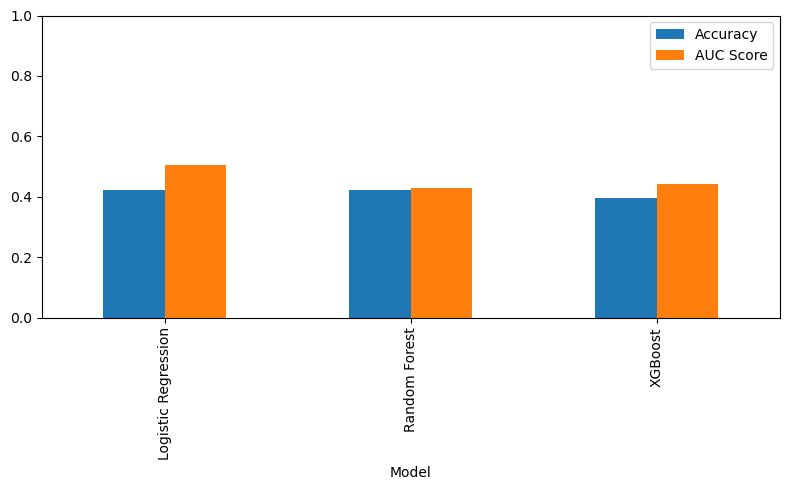

In [6]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"] + (["XGBoost"] if "xgb_acc" in globals() else []),
    "Accuracy": [lr_acc, rf_acc] + ([xgb_acc] if "xgb_acc" in globals() else []),
    "AUC Score": [lr_auc, rf_auc] + ([xgb_auc] if "xgb_acc" in globals() else [])
})

print(results)

results.plot(x="Model", y=["Accuracy", "AUC Score"], kind="bar", figsize=(8,5))
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

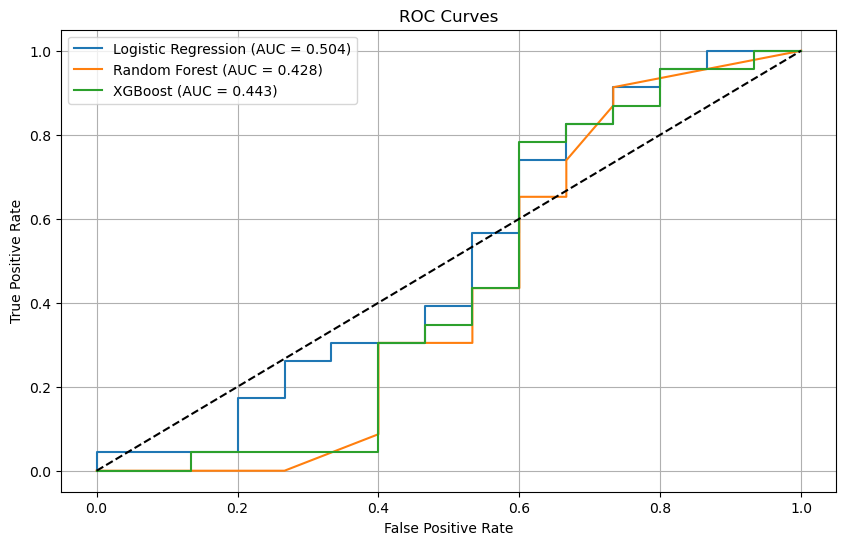

In [7]:
plt.figure(figsize=(10,6))

models = {"Logistic Regression": lr_prob, "Random Forest": rf_prob}
if "xgb_prob" in globals():
    models["XGBoost"] = xgb_prob

for name, prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, prob):.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

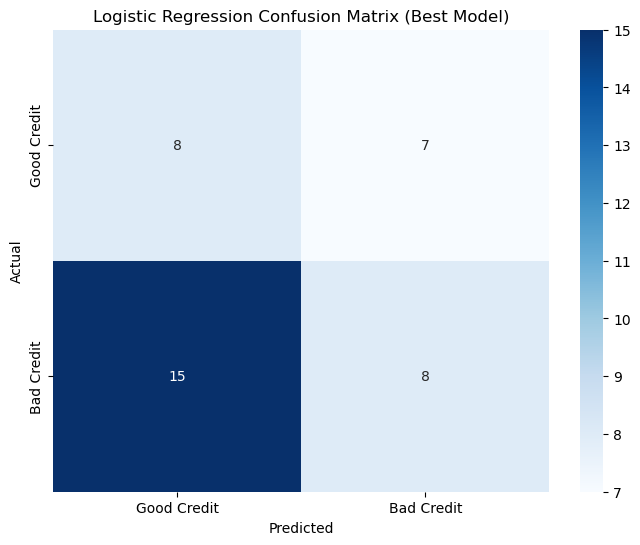


Best Model by AUC: Logistic Regression (AUC = 0.5043)

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.35      0.53      0.42        15
  Bad Credit       0.53      0.35      0.42        23

    accuracy                           0.42        38
   macro avg       0.44      0.44      0.42        38
weighted avg       0.46      0.42      0.42        38



In [8]:
# Pick the best model by comparing actual test AUC across all trained models,
# instead of assuming XGBoost is best just because it ran.
candidates = {"Logistic Regression": (lr_model, lr_auc, lr_acc, lr_pred)}
candidates["Random Forest"] = (rf_model, rf_auc, rf_acc, rf_pred)
if "xgb_model" in globals():
    candidates["XGBoost"] = (xgb_model, xgb_auc, xgb_acc, xgb_pred)

best_model_name = max(candidates, key=lambda name: candidates[name][1])
best_model, best_auc, best_acc, best_pred = candidates[best_model_name]

plt.figure(figsize=(8,6))

cm = confusion_matrix(y_test, best_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Good Credit", "Bad Credit"],
            yticklabels=["Good Credit", "Bad Credit"])

plt.title(f"{best_model_name} Confusion Matrix (Best Model)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(f"\nBest Model by AUC: {best_model_name} (AUC = {best_auc:.4f})")
print("\nClassification Report:")
print(classification_report(
    y_test, best_pred,
    target_names=["Good Credit", "Bad Credit"]
))

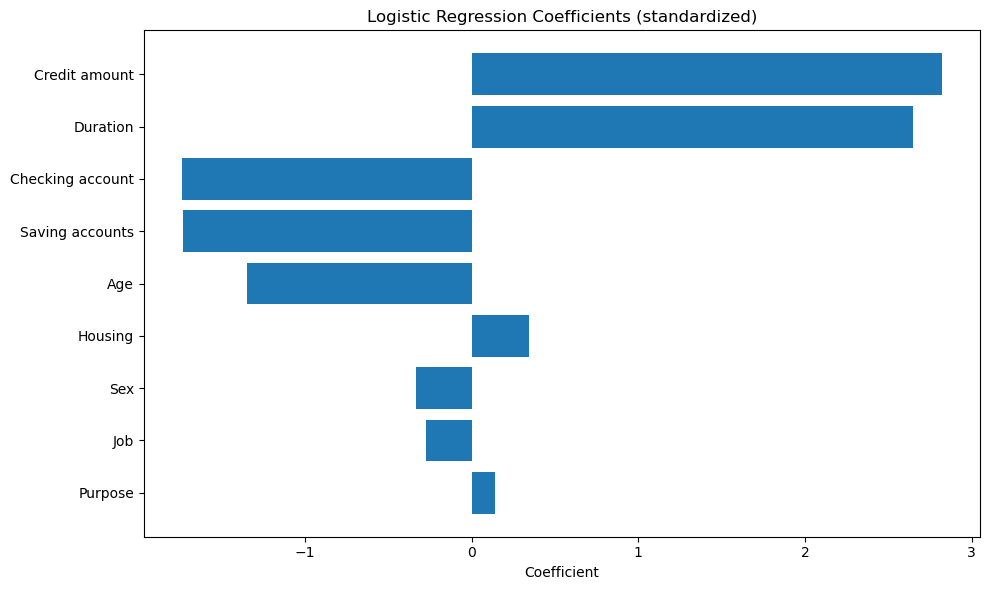

In [9]:
plt.figure(figsize=(10,6))

# Use the best model (by AUC) for feature importance if it exposes one;
# tree-based models (RF, XGBoost) have feature_importances_, LR does not.
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance")

    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.title(f"{best_model_name} Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    # Logistic Regression: show absolute standardized coefficients instead,
    # since coefficients (not feature_importances_) are its native measure.
    coef_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": best_model.coef_[0]
    }).sort_values("Coefficient", key=np.abs)

    plt.barh(coef_df["Feature"], coef_df["Coefficient"])
    plt.title(f"{best_model_name} Coefficients (standardized)")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

In [10]:
# Relative path so the notebook works on any machine / after cloning the repo
models_path = os.path.join("..", "models")
os.makedirs(models_path, exist_ok=True)

joblib.dump(lr_model, os.path.join(models_path, "logistic_regression.pkl"))
joblib.dump(rf_model, os.path.join(models_path, "random_forest.pkl"))
joblib.dump(scaler, os.path.join(models_path, "scaler.pkl"))  # needed to use lr_model on new data

if "xgb_model" in globals():
    joblib.dump(xgb_model, os.path.join(models_path, "xgboost_model.pkl"))

print(f"Best Model: {best_model_name}")
print(f"AUC: {best_auc:.4f}")
print(f"Accuracy: {best_acc:.4f}")

print("\nModels saved successfully!")

Best Model: Logistic Regression
AUC: 0.5043
Accuracy: 0.4211

Models saved successfully!


## Best Performing Model: Logistic Regression

Based on the evaluation metrics, **Logistic Regression** was selected as the best-performing model.

- **Accuracy:** **42.11%** (tied with Random Forest)
- **AUC Score:** **0.5043** (highest among all models)

Although Logistic Regression achieved the highest AUC score and matched the highest accuracy, its overall predictive performance is relatively weak. An AUC score close to **0.50** indicates that the model performs only slightly better than random guessing. This suggests that further improvements in data preprocessing, feature engineering, and model tuning are required to build a more reliable credit risk prediction model.